# 🏀 NBA Finals Ticket Price Tracker
Track SeatGeek get-in prices for each Finals game and visualize how they change over time.

**How to use:**
1. Run cells 1–3 once to set up (installs packages, creates database)
2. Each time you check SeatGeek, run **Cell 4 (log prices)** and enter what you see
3. Run **Cell 5** anytime to see the trend chart


In [10]:
# CELL 1 — Setup (run once per session)

import subprocess, sqlite3, pandas as pd
from pathlib import Path
from datetime import datetime, date

subprocess.run(["pip", "install", "requests", "matplotlib"], capture_output=True)

# ── Database ──────────────────────────────────────────────────────────────────

DB_PATH = Path("nba_finals_prices.db")

GAMES = [
    {"id": "g2",  "date": "Jun 5",  "game_date": date(2026, 6, 5),  "venue": "SA",  "label": "Game 2 — San Antonio  (Jun 5)"},
    {"id": "g3",  "date": "Jun 8",  "game_date": date(2026, 6, 8),  "venue": "NYC", "label": "Game 3 — New York      (Jun 8)"},
    {"id": "g4",  "date": "Jun 10", "game_date": date(2026, 6, 10), "venue": "NYC", "label": "Game 4 — New York      (Jun 10)"},
    {"id": "g5",  "date": "Jun 13", "game_date": date(2026, 6, 13), "venue": "SA",  "label": "Game 5 — San Antonio  (Jun 13, if needed)"},
    {"id": "g6",  "date": "Jun 16", "game_date": date(2026, 6, 16), "venue": "NYC", "label": "Game 6 — New York      (Jun 16, if needed)"},
    {"id": "g7",  "date": "Jun 19", "game_date": date(2026, 6, 19), "venue": "SA",  "label": "Game 7 — San Antonio  (Jun 19, if needed)"},
]

BASELINE = {
    "g2": 838, "g3": 6476, "g4": 6718,
    "g5": 1650, "g6": 7276, "g7": 3902,
}

conn = sqlite3.connect(DB_PATH)
conn.execute("""
    CREATE TABLE IF NOT EXISTS prices (
        id        INTEGER PRIMARY KEY AUTOINCREMENT,
        game_id   TEXT    NOT NULL,
        price     INTEGER NOT NULL,
        notes     TEXT,
        logged_at TEXT    NOT NULL
    )
""")
conn.commit()

count = conn.execute("SELECT COUNT(*) FROM prices").fetchone()[0]
if count == 0:
    ts = "2026-06-03T23:00:00"
    for gid, price in BASELINE.items():
        conn.execute(
            "INSERT INTO prices (game_id, price, notes, logged_at) VALUES (?,?,?,?)",
            (gid, price, "Initial snapshot Jun 3", ts)
        )
    conn.commit()
    print("Database created and seeded with Jun 3 baseline prices")
else:
    print(f"Database ready ({count} entries logged)")

conn.close()

# ── Helper functions ──────────────────────────────────────────────────────────

def log_price(game_id, price, notes=""):
    conn = sqlite3.connect(DB_PATH)
    conn.execute(
        "INSERT INTO prices (game_id, price, notes, logged_at) VALUES (?,?,?,?)",
        (game_id, price, notes, datetime.now().isoformat(timespec="seconds"))
    )
    conn.commit()
    conn.close()

def get_all_prices():
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql("SELECT * FROM prices ORDER BY logged_at", conn)
    conn.close()
    df["logged_at"] = pd.to_datetime(df["logged_at"])
    game_map = {g["id"]: g["label"] for g in GAMES}
    df["game_label"] = df["game_id"].map(game_map)
    return df

def latest_prices():
    df = get_all_prices()
    return df.sort_values("logged_at").groupby("game_id").last().reset_index()

print("Setup complete")

Database ready (36 entries logged)
Setup complete


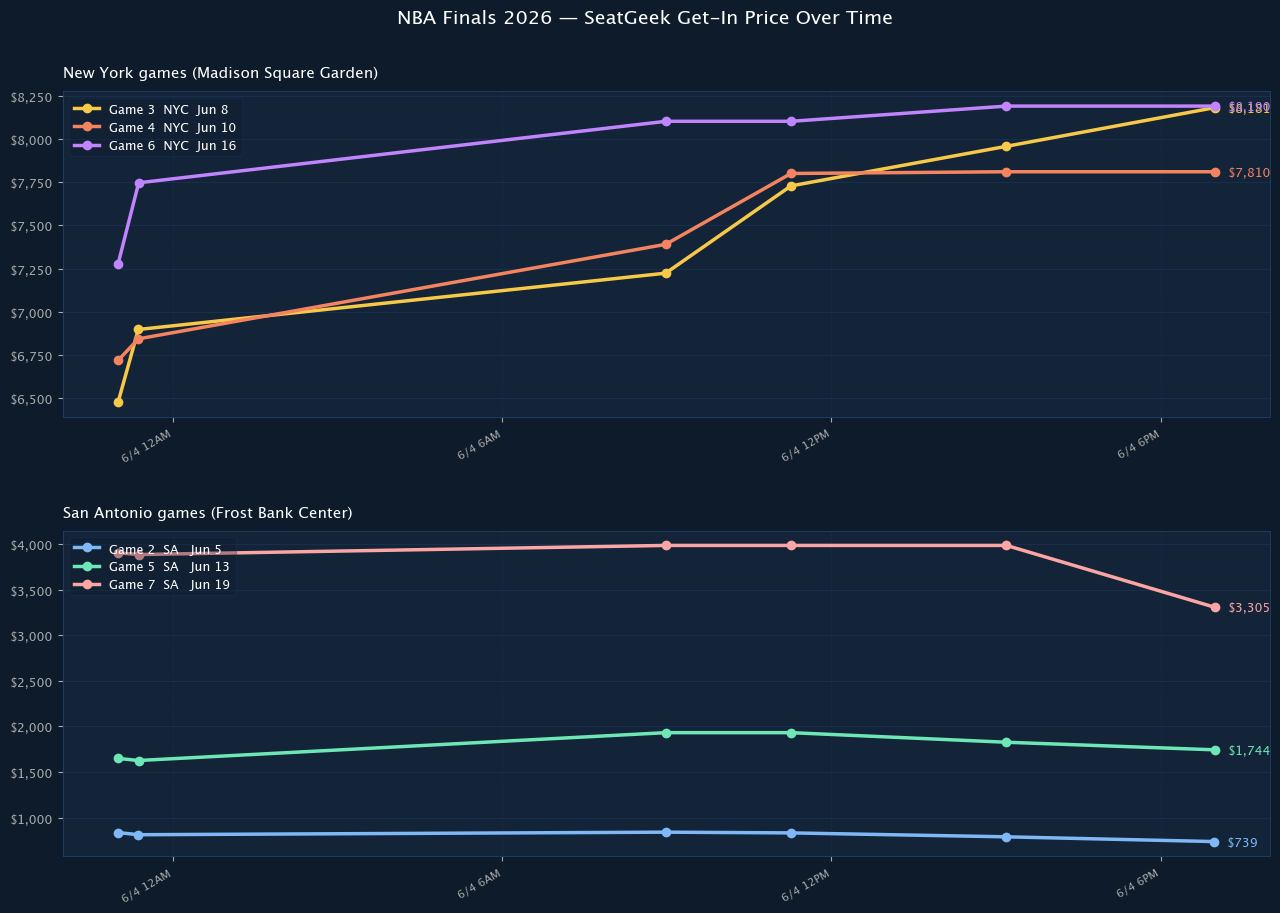

Chart saved as nba_finals_chart.png


In [9]:
# CELL 5 (updated) — Split chart with dark navy background
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = get_all_prices()

GAMES_META = [
    {"id": "g2",  "venue": "SA",  "label": "Game 2  SA   Jun 5",  "color": "#7EB8F7"},
    {"id": "g3",  "venue": "NYC", "label": "Game 3  NYC  Jun 8",  "color": "#F7C948"},
    {"id": "g4",  "venue": "NYC", "label": "Game 4  NYC  Jun 10", "color": "#F4845F"},
    {"id": "g5",  "venue": "SA",  "label": "Game 5  SA   Jun 13", "color": "#6EE7B7"},
    {"id": "g6",  "venue": "NYC", "label": "Game 6  NYC  Jun 16", "color": "#C084FC"},
    {"id": "g7",  "venue": "SA",  "label": "Game 7  SA   Jun 19", "color": "#FCA5A5"},
]

NAVY = "#0D1B2A"
PANEL = "#132338"
GRID  = "#1E3A5F"

nyc_games = [g for g in GAMES_META if g["venue"] == "NYC"]
sa_games  = [g for g in GAMES_META if g["venue"] == "SA"]

fig, (ax_nyc, ax_sa) = plt.subplots(2, 1, figsize=(13, 9), sharex=False)
fig.patch.set_facecolor(NAVY)

def plot_panel(ax, games, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10,
                 loc="left", color="white")
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

    for game in games:
        gdf = df[df["game_id"] == game["id"]].sort_values("logged_at")
        if gdf.empty:
            continue
        ax.plot(
            gdf["logged_at"], gdf["price"],
            marker="o", linewidth=2.5, markersize=6,
            color=game["color"], label=game["label"]
        )
        last = gdf.iloc[-1]
        ax.annotate(
            f'${int(last["price"]):,}',
            xy=(last["logged_at"], last["price"]),
            xytext=(9, 0), textcoords="offset points",
            fontsize=9, color=game["color"], va="center", fontweight="bold"
        )

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%-m/%-d %-I%p"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right",
             fontsize=8, color="#AAAAAA")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x):,}"))
    ax.tick_params(axis="y", labelsize=9, colors="#AAAAAA")
    ax.tick_params(axis="x", colors="#AAAAAA")
    legend = ax.legend(fontsize=9, loc="upper left", framealpha=0.3,
                       facecolor=NAVY, edgecolor=GRID, labelcolor="white")
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.grid(axis="x", color=GRID, linewidth=0.5, linestyle="--")

plot_panel(ax_nyc, nyc_games, "New York games (Madison Square Garden)")
plot_panel(ax_sa,  sa_games,  "San Antonio games (Frost Bank Center)")

fig.suptitle("NBA Finals 2026 — SeatGeek Get-In Price Over Time",
             fontsize=14, fontweight="bold", color="white", y=1.01)

plt.tight_layout(h_pad=3)
plt.savefig("nba_finals_chart.png", dpi=150, bbox_inches="tight",
            facecolor=NAVY)
plt.show()
print("Chart saved as nba_finals_chart.png")


In [11]:
# Cell 6 — Summary table with all logged prices
df = get_all_prices()
df_display = df[["game_label", "price", "logged_at", "notes"]].copy()
df_display.columns = ["Game", "Price", "Logged at", "Notes"]
df_display["Price"] = df_display["Price"].apply(lambda x: f"${int(x):,}")
df_display["Logged at"] = df_display["Logged at"].astype(str).str[:16]
df_display = df_display.sort_values("Logged at", ascending=False)
df_display

,Game,Price,Logged at,Notes
35,"Game 7 — San Antonio (Jun 19, if needed)","$3,305",2026-06-04 18:59,
34,"Game 6 — New York (Jun 16, if needed)","$8,190",2026-06-04 18:59,
33,"Game 5 — San Antonio (Jun 13, if needed)","$1,744",2026-06-04 18:59,
32,Game 4 — New York (Jun 10),"$7,810",2026-06-04 18:59,
31,Game 3 — New York (Jun 8),"$8,181",2026-06-04 18:59,
30,Game 2 — San Antonio (Jun 5),$739,2026-06-04 18:58,
26,Game 4 — New York (Jun 10),"$7,810",2026-06-04 15:11,
24,Game 2 — San Antonio (Jun 5),$791,2026-06-04 15:11,
25,Game 3 — New York (Jun 8),"$7,957",2026-06-04 15:11,
28,"Game 6 — New York (Jun 16, if needed)","$8,190",2026-06-04 15:11,
